In [1]:
import sys
import torch
import ultralytics

print("Python :", sys.executable)
print("Torch  :", torch.__version__)
print("CUDA   :", torch.cuda.is_available())
print("GPU    :", torch.cuda.get_device_name(0))
print("YOLO   :", ultralytics.__version__)

WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\rifat\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python : d:\Software\Python_Environments\ai_cv\python.exe
Torch  : 2.7.1+cu118
CUDA   : True
GPU    : NVIDIA GeForce GTX 1650 SUPER
YOLO   : 8.4.115


In [2]:
import torch
import torchvision

model = torchvision.models.resnet18(weights=None).cuda()

optimizer = torch.optim.Adam(model.parameters())
criterion = torch.nn.CrossEntropyLoss()

x = torch.randn(8, 3, 224, 224).cuda()
y = torch.randint(0, 1000, (8,)).cuda()

for i in range(20):
    optimizer.zero_grad()

    output = model(x)

    loss = criterion(output, y)

    loss.backward()

    optimizer.step()

print("PyTorch GPU Training Successful!")

PyTorch GPU Training Successful!


In [8]:
from pathlib import Path


dataset = Path("../../Datasets_for_my_practice/road_objects/Road-Anomalies-1/")

data_yaml = dataset / "data.yaml"

print(data_yaml)
print(data_yaml.exists())

..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\data.yaml
True


In [5]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

train_results = model.train(
    data=data_yaml,
    epochs=50,
    imgsz=640,
    batch=8,          # Good starting point for 4GB VRAM
    workers=2,        # Start conservatively on Windows
    device=0,
    project="runs",
    name="road_objects",
    exist_ok=True
)

Ultralytics 8.4.115  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 SUPER, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1

d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\nn\modules\block.py:1325: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q * self.scale).transpose(-2, -1) @ k
d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\nn\modules\block.py:1327: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setD


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\utils\loss.py:397: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))
d:\Software\Python_Environments\ai_cv\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algori

       1/50      2.49G      1.796       4.66      1.552         19        640: 100% ━━━━━━━━━━━━ 250/250 2.8it/s 1:310.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.0it/s 3.2s0.2s
                   all        250        930      0.902     0.0915     0.0926     0.0597

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      48/50      2.45G      1.182      1.042      1.163         19        640: 100% ━━━━━━━━━━━━ 250/250 4.5it/s 55.5s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.9it/s 2.7s0.2s
                   all        250        930       0.52      0.415      0.397      0.233

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\nn\modules\block.py:1325: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q * self.scale).transpose(-2, -1) @ k
d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\nn\modules\block.py:1327: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setD

      49/50      2.44G      1.183      1.045      1.148         15        640: 100% ━━━━━━━━━━━━ 250/250 4.5it/s 55.5s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.9it/s 2.7s0.2s
                   all        250        930      0.536      0.415      0.397      0.233

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\nn\modules\block.py:1325: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:233.)
  attn = (q * self.scale).transpose(-2, -1) @ k
d:\Software\Python_Environments\ai_cv\lib\site-packages\ultralytics\nn\modules\block.py:1327: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setD

      50/50      2.45G      1.167      1.039      1.139         42        640: 100% ━━━━━━━━━━━━ 250/250 4.4it/s 56.2s0.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.1it/s 2.6s0.2s
                   all        250        930      0.542       0.41      0.398      0.234

50 epochs completed in 0.841 hours.
Optimizer stripped from D:\Programming File\My AI ML Code Practice\week_4\runs\detect\runs\road_objects\weights\last.pt, 5.5MB
Optimizer stripped from D:\Programming File\My AI ML Code Practice\week_4\runs\detect\runs\road_objects\weights\best.pt, 5.5MB

Validating D:\Programming File\My AI ML Code Practice\week_4\runs\detect\runs\road_objects\weights\best.pt...
Ultralytics 8.4.115  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 SUPER, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,585,857 parameters, 0 gradients, 6.4 GFLOPs
                 Class     Images  Instances      Box(P          R   

In [6]:
from pathlib import Path

best_model = Path("runs/detect/runs/road_objects/weights/best.pt")

model = YOLO(best_model)

In [9]:
from ultralytics import YOLO


test_images = sorted((dataset / "test/images").glob("*"))

image_path = test_images[5]

results = model.predict(
    source=image_path,
    conf=0.25
)


image 1/1 d:\Programming File\My AI ML Code Practice\week_4\..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\test\images\2_1095_png_jpg.rf.563c859f90c83b3fc382b54f77c07b44.jpg: 640x640 4 Lanes, 15.1ms
Speed: 78.7ms preprocess, 15.1ms inference, 13.5ms postprocess per image at shape (1, 3, 640, 640)


In [10]:
print(type(results))
print(len(results))
print(type(results[0]))
print(results[0])

<class 'list'>
1
<class 'ultralytics.engine.results.Results'>
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'Cracks', 1: 'Lane', 2: 'SpeedBreaker', 3: 'Speed_Breaker', 4: 'bicycle', 5: 'bus', 6: 'car', 7: 'construction sign', 8: 'crosswalk', 9: 'motorcycle', 10: 'one way sign', 11: 'pedestrian crossing sign', 12: 'person', 13: 'pothole', 14: 'railroad sign', 15: 'stop sign', 16: 'street name sign', 17: 'traffic light', 18: 'truck'}
obb: None
orig_img: array([[[169, 149, 144],
        [106,  86,  81],
        [107,  88,  81],
        ...,
        [  3,   4,   0],
        [  3,   4,   0],
        [  3,   4,   0]],

       [[119,  99,  94],
        [177, 158, 151],
        [172, 153, 146],
        ...,
        [  3,   4,   0],
        [  3,   4,   0],
        [  3,   4,   0]],

       [[172, 153, 146],
        [228, 209, 202],
        [255, 240, 233],
        ...,
        [  3, 

In [11]:
boxes = results[0].boxes

print(type(boxes))
print(boxes)

<class 'ultralytics.engine.results.Boxes'>
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 1.], device='cuda:0')
conf: tensor([0.9091, 0.9091, 0.6489, 0.3202], device='cuda:0')
data: tensor([[0.0000e+00, 1.2039e+02, 3.0161e+02, 3.0512e+02, 9.0911e-01, 1.0000e+00],
        [4.3331e+02, 1.7106e+02, 6.3933e+02, 2.8896e+02, 9.0906e-01, 1.0000e+00],
        [3.4120e+02, 1.2521e+02, 3.6383e+02, 1.3441e+02, 6.4895e-01, 1.0000e+00],
        [3.3917e+02, 1.2325e+02, 3.6335e+02, 1.3372e+02, 3.2019e-01, 1.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([4, 6])
xywh: tensor([[150.8035, 212.7535, 301.6069, 184.7272],
        [536.3186, 230.0091, 206.0261, 117.9053],
        [352.5132, 129.8102,  22.6271,   9.1956],
        [351.2580, 128.4848,  24.1758,  10.4630]], device='cuda:0')
xywhn: tensor([[0.2356, 0.3324, 0.4713, 0.2886],
        [0.8380, 0.3594, 0.3219, 0.1842],
        [0.5508, 0.2028, 0.0354, 0.0144],
     

In [15]:
print(boxes.xyxy)

tensor([[  0.0000, 120.3899, 301.6069, 305.1171],
        [433.3055, 171.0564, 639.3317, 288.9617],
        [341.1996, 125.2124, 363.8267, 134.4080],
        [339.1701, 123.2533, 363.3459, 133.7163]], device='cuda:0')


In [16]:
for box in boxes:
    print("Box:", box.xyxy)
    print("Confidence:", float(box.conf))
    print("Class ID:", int(box.cls))
    print("Class Name:", results[0].names[int(box.cls)])
    print("-" * 40)

Box: tensor([[  0.0000, 120.3899, 301.6069, 305.1171]], device='cuda:0')
Confidence: 0.909111499786377
Class ID: 1
Class Name: Lane
----------------------------------------
Box: tensor([[433.3055, 171.0564, 639.3317, 288.9617]], device='cuda:0')
Confidence: 0.909063994884491
Class ID: 1
Class Name: Lane
----------------------------------------
Box: tensor([[341.1996, 125.2124, 363.8267, 134.4080]], device='cuda:0')
Confidence: 0.6489459872245789
Class ID: 1
Class Name: Lane
----------------------------------------
Box: tensor([[339.1701, 123.2533, 363.3459, 133.7163]], device='cuda:0')
Confidence: 0.3201892673969269
Class ID: 1
Class Name: Lane
----------------------------------------


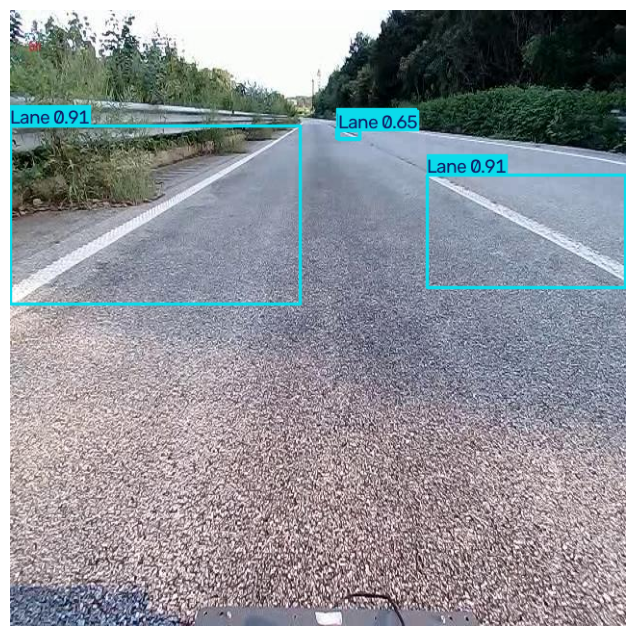

In [12]:
import cv2
import matplotlib.pyplot as plt

annotated_image = results[0].plot()

# Convert BGR -> RGB
annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

In [13]:
test_folder = dataset / "test/images"

results = model.predict(
    source=test_folder,
    conf=0.25,
    save=True
)


image 1/250 d:\Programming File\My AI ML Code Practice\week_4\..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\test\images\0lR8jj27kbp1Hj0ELcpbrQ_jpg.rf.fc1edb0fccc0847c6b0f6da5c36a585e.jpg: 640x640 (no detections), 158.4ms
image 2/250 d:\Programming File\My AI ML Code Practice\week_4\..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\test\images\1Q1PEmoEFuhuiDUye-tn2A_jpg.rf.45f5542a96629b012fa4a3c08d63783d.jpg: 640x640 7 cars, 2 pedestrian crossing signs, 2 trucks, 16.1ms
image 3/250 d:\Programming File\My AI ML Code Practice\week_4\..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\test\images\1cdvBDmZlEHXRPi6j4OTig_jpg.rf.1fee5d2348adfba227fa729fd87a4f7d.jpg: 640x640 7 cars, 1 pedestrian crossing sign, 15.2ms
image 4/250 d:\Programming File\My AI ML Code Practice\week_4\..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\test\images\20tnqeqDWXkECQDJkJTofw_jpg.rf.3f3a1ea3c134f020fb53aa70b3f1ce8a.jpg: 640x640 7 cars, 1 construction sign, 1 pe

In [14]:
print(len(results))

250
